# Sentinel-3 OLCI True Colour Under Sentinel-5P Products

This notebook converts the Sentinel Hub
[OLCI true colour under Sentinel-5P products](https://custom-scripts.sentinel-hub.com/data-fusion/olci_under_s5/)
data-fusion evalscript into a reusable openEO User-Defined Process (UDP).

**Sentinel-5P** (TROPOMI) measures atmospheric composition -- trace gases,
aerosols, and cloud properties -- at a coarse ~7 km footprint, once a day,
everywhere on Earth. Its products are frequently incomplete: cloud cover, sun
glint, polar night, or a failed retrieval all leave gaps with no value.
**Sentinel-3 OLCI** flies alongside it and provides a 300 m true-colour image
with none of those gaps (during daylight).

This script overlays the Sentinel-5P product on top of the OLCI true-colour
image: wherever Sentinel-5P has a valid measurement, it is drawn as a six-stop
colour ramp; wherever it does not, the OLCI true-colour pixel shows through.
The result is a single image that is never empty, and that gives atmospheric
data spatial context it would otherwise lack.

## Overview

In this notebook we will:

1. Connect to CDSE -- the only backend in this repository serving Sentinel-5P
2. Load a Sentinel-3 OLCI true-colour scene and a single Sentinel-5P
   atmospheric product for the same area and date
3. Fuse them onto OLCI's 300 m grid
4. Implement the colour-ramp visualisation (`colorBlend`) and the gap-fill logic
5. Verify the retrieval against a numpy reimplementation, pixel by pixel
6. Visualise the result, then repeat it for three more product/location pairs --
   SO2 over Mt Etna, NO2 over the Po Valley, and CO over the 2019 Chiquitania
   wildfires
7. Export the process graph as a parameterised UDP

## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/data-fusion/olci_under_s5/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)

## Scientific Background

### Why fuse these two missions

Sentinel-3 OLCI and Sentinel-5P TROPOMI fly on separate satellites, at very
different resolutions and swath geometries, but Sentinel-5 Precursor's orbit is
close enough to Sentinel-3's that same-day coverage over one AOI is routine.
TROPOMI's ~7 x 3.5 km footprint already integrates the atmosphere over an area
far larger than a single OLCI pixel; overlaying rather than reprojecting it down
keeps the display honest about that difference in support.

### The Sentinel-5P products

CDSE's `SENTINEL_5P_L2` collection carries fourteen L2 products, each its own
band (see `S5P_PRODUCT_RANGES` below), each with its own physical unit and
plausible range:

| Product | Unit | Description |
|---|---|---|
| `CO` | mol/m^2 | Carbon monoxide total column |
| `HCHO` | mol/m^2 | Formaldehyde total column |
| `NO2` | mol/m^2 | Nitrogen dioxide total column |
| `O3` | mol/m^2 | Ozone total column |
| `SO2` | mol/m^2 | Sulphur dioxide total column |
| `CH4` | ppb | Methane column-averaged mixing ratio |
| `AER_AI_340_380`, `AER_AI_354_388` | -- | UV Aerosol Index (two wavelength pairs) |
| `CLOUD_TOP_PRESSURE`, `CLOUD_BASE_PRESSURE` | Pa | Cloud top/base pressure |
| `CLOUD_TOP_HEIGHT`, `CLOUD_BASE_HEIGHT` | m | Cloud top/base height |
| `CLOUD_OPTICAL_THICKNESS` | -- | Cloud optical thickness |
| `CLOUD_FRACTION` | -- | Cloud fraction |

CDSE's own STAC description of this collection states it **only supports
loading one band at a time** -- there is no way to request several products in
a single `load_collection` call, so the algorithm always operates on exactly
one.

### The `colorBlend` visualisation

The original evalscript hand-rolls Sentinel Hub's `colorBlend` helper: six
anchor points spaced at 0%, 12.5%, 37.5%, 62.5%, 87.5% and 100% between a
product's `minVal` and `maxVal`, each assigned a fixed colour (dark blue -> blue
-> cyan -> yellow -> red -> dark red), with linear interpolation between
neighbouring anchors. The same six colours are reused for every product; only
`minVal`/`maxVal` change. This notebook reimplements that as a small nested
`if_` cascade per RGB channel (`color_blend_channel` below), built from a shared
`S5P_PRODUCT_RANGES` lookup table -- so switching products is a one-line change
rather than a hand-edit of the colour logic.

### The gap-fill test

The evalscript's validity test is simply `value > 0`: wherever the S5P band is
positive, draw the colour ramp; otherwise fall through to the OLCI true-colour
composite `[B08*3, B06*3, B04*3.5]`. This is not a proper no-data mask -- a
`dataMask` band exists in the collection but the original script does not use
it -- see the limitations section for what that costs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from PIL import Image
from openeo.processes import array_create, if_

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to
CDSE -- the only endpoint in this repository with a Sentinel-5P mapping.

In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "olci_under_s5"

# Initialize parameter manager
param_manager = ParameterManager("olci_under_s5.params.py")

# Display available options using the built-in helper
param_manager.print_options("OLCI-under-Sentinel-5P data fusion algorithm")

Available parameter sets for OLCI-under-Sentinel-5P data fusion algorithm:
  1. etna_sicily_cloud_pressure: Mt Etna, Sicily, Italy (cloud top pressure)
  2. etna_sicily_so2: Mt Etna, Sicily, Italy (SO2 degassing)
  3. po_valley_no2: Po Valley, Italy (NO2)
  4. chiquitania_co: Chiquitania, Bolivia (wildfire CO)

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# Only CDSE serves Sentinel-5P; keep the endpoint in a variable so the S5P
# collection/bands can be routed through the SAME endpoint mapper below.
_endpoint = "copernicus_dataspace"
_primary_set = "etna_sicily_cloud_pressure"

connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=_endpoint,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: etna_sicily_cloud_pressure


Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Mt Etna, Sicily, Italy (cloud top pressure)
🔄 Parameters mapped for endpoint copernicus_dataspace:
  collection: sentinel-3-olci-l1b -> SENTINEL3_OLCI_L1B
  bands: ['b04', 'b06', 'b08'] -> ['B04', 'B06', 'B08']


## Load the True-Colour Base and the Atmospheric Product

**OLCI** flows through the standard parameter mapping (`collection`/`bands`);
the **Sentinel-5P** collection/band are routed through the same endpoint mapper
explicitly, exactly as the Sentinel-3 Land Surface Temperature notebook routes
its second collection -- because the automatic mapping in `quick_connect` only
handles one `collection`/`bands` pair.

Both are reduced over time with `"mean"` to collapse to a single acquisition;
each parameter set's time window is one day wide, chosen so both missions have
exactly one overpass in it.

In [4]:
bbox = current_params["bounding_box"]
time = current_params["time"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]

# Route the Sentinel-5P collection/band through the same endpoint mapper.
_s5p = param_manager.apply_endpoint_mapping(
    {
        "collection": current_params["s5p_collection"],
        "bands": current_params["s5p_bands"],
    },
    _endpoint,
)

# --- OLCI: 300 m true-colour base map (0-1 reflectance) ---
olci = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=current_params["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="mean")

# --- Sentinel-5P: one atmospheric product, ~7 km footprint ---
s5p = connection.load_collection(
    _s5p["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=_s5p["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="mean")

print(f"OLCI bands: {current_params['bands'].default} (0-1 reflectance)")
print(f"S5P product: {_s5p['bands'].default} (native units, see S5P_PRODUCT_RANGES)")
print("✅ Loaded the true-colour base and the atmospheric product")

OLCI bands: ['B04', 'B06', 'B08'] (0-1 reflectance)
S5P product: ['CLOUD_TOP_PRESSURE'] (native units, see S5P_PRODUCT_RANGES)
✅ Loaded the true-colour base and the atmospheric product


## Fuse onto a Common Grid

OLCI is 300 m; Sentinel-5P is on a roughly 7 km grid. The S5P band is resampled
onto the OLCI grid with nearest-neighbour, matching the blocky rendering the
original evalscript produces in EO Browser -- resampling does not, and should
not, invent sub-pixel structure that a ~7 km retrieval does not have. Band names
do not collide (`B04`/`B06`/`B08` vs. e.g. `CLOUD_TOP_PRESSURE`), so no
relabelling is needed.

In [5]:
fused = olci.merge_cubes(s5p.resample_cube_spatial(olci, method="near"))

EXPECTED_BANDS = [*current_params["bands"].default, *_s5p["bands"].default]
fused_bands = fused.metadata.band_names
print("Fused band order:", fused_bands)
assert fused_bands == EXPECTED_BANDS, f'expected {EXPECTED_BANDS}, got {fused_bands}'

Fused band order: ['B04', 'B06', 'B08', 'CLOUD_TOP_PRESSURE']


## Implement the Colour Ramp and the Gap-Fill Logic

`S5P_PRODUCT_RANGES` gives every one of CDSE's fourteen products the
`(minVal, maxVal)` pair from the evalscript's own comment block (verbatim,
including its unit). `color_blend_channel` builds one RGB channel of the
evalscript's `colorBlend` as a nested `if_` cascade: five linear segments
between six colour anchors, walked from the highest segment down so the first
satisfied `<=` test wins -- structurally the same nested-`if_` pattern used for
the emissivity classification in the Sentinel-3 LST notebook.

`olci_under_s5` is the reducer applied across the fused bands: wherever the S5P
product is positive it draws the colour ramp; otherwise it falls through to the
OLCI true-colour composite `[B08*3, B06*3, B04*3.5]`, clipped to `[0, 1]`
because `* 3`/`* 3.5` can legitimately push a bright pixel above 1.

In [6]:
# (minVal, maxVal) verbatim from the evalscript's own comment block -- every
# product shares the same six-colour ramp, only the range differs.
S5P_PRODUCT_RANGES = {
    "cloud_top_pressure": (10000.0, 110000.0),   # Pa
    "cloud_base_pressure": (10000.0, 110000.0),  # Pa
    "cloud_top_height": (0.0, 20000.0),          # m
    "cloud_base_height": (0.0, 20000.0),         # m
    "cloud_optical_thickness": (0.0, 250.0),
    "cloud_fraction": (0.0, 1.0),
    "aer_ai_340_380": (-1.0, 5.0),
    "aer_ai_354_388": (-1.0, 5.0),
    "co": (0.0, 0.1),        # mol/m^2
    "hcho": (0.0, 0.001),    # mol/m^2
    "no2": (0.0, 0.0001),    # mol/m^2
    "o3": (0.0, 0.36),       # mol/m^2
    "so2": (0.0, 0.01),      # mol/m^2
    "ch4": (1600.0, 2000.0),  # ppb
}

# Dark blue -> blue -> cyan -> yellow -> red -> dark red, shared by every product.
COLOR_RAMP = [
    (0.0, 0.0, 0.5), (0.0, 0.0, 1.0), (0.0, 1.0, 1.0),
    (1.0, 1.0, 0.0), (1.0, 0.0, 0.0), (0.5, 0.0, 0.0),
]
RAMP_FRACTIONS = (0.0, 0.125, 0.375, 0.625, 0.875, 1.0)


def limits_for(product):
    """The six colorBlend anchor values for one product's (min, max) range."""
    min_val, max_val = S5P_PRODUCT_RANGES[product]
    diff = max_val - min_val
    return [min_val + f * diff for f in RAMP_FRACTIONS]


def color_blend_channel(value, limits, channel_idx):
    """One RGB channel of colorBlend: linear interpolation between six anchors.

    Built from the last segment inward so each `if_` only needs an upper-bound
    test -- the first (innermost, highest) segment whose `hi` the value clears
    is the one whose interpolated value survives every outer if_.
    """
    expr = COLOR_RAMP[-1][channel_idx]
    for i in range(len(limits) - 2, -1, -1):
        lo, hi = limits[i], limits[i + 1]
        c_lo, c_hi = COLOR_RAMP[i][channel_idx], COLOR_RAMP[i + 1][channel_idx]
        frac = (value - lo) / (hi - lo)
        interp = c_lo + frac * (c_hi - c_lo)
        expr = if_(value <= hi, interp, expr)
    return expr


# The product is algorithm-intrinsic (baked in via .default), not a runtime
# UDP parameter -- see the .params.py module docstring for why.
_product = param_manager.get_parameter("s5p_bands", _primary_set).default[0]
_limits = limits_for(_product)


def olci_under_s5(data):
    """Colour ramp where the product has data; OLCI true colour otherwise."""
    b04, b06, b08, product_value = data[0], data[1], data[2], data[3]

    # The evalscript's own validity test -- not a proper no-data mask, see
    # the limitations section.
    has_data = product_value > 0

    r = if_(has_data, color_blend_channel(product_value, _limits, 0), (b08 * 3).clip(min=0, max=1))
    g = if_(has_data, color_blend_channel(product_value, _limits, 1), (b06 * 3).clip(min=0, max=1))
    b = if_(has_data, color_blend_channel(product_value, _limits, 2), (b04 * 3.5).clip(min=0, max=1))
    return array_create([r, g, b])

## Apply the Fusion and Save

The reducer runs across the fused bands dimension, producing a 3-band RGB cube
in `[0, 1]`, then scaled to 8-bit for a viewable PNG -- this is a visualisation
script by design (unlike the LST notebook, which exports a physical quantity),
so an RGB image is the faithful output format here.

In [7]:
rgb_cube = fused.reduce_dimension(dimension=bands_dim, reducer=olci_under_s5)
rgb_cube = rgb_cube.linear_scale_range(0, 1, 0, 255)
rgb_result = rgb_cube.save_result("PNG")

## Verify the Fusion Against a Numpy Reimplementation

**This runs before the full-scene visualisation on purpose.** The fused raw
bands are downloaded once, and `color_blend_channel`'s nested `if_` cascade is
reproduced in numpy (`np_color_blend`) alongside the same gap-fill test, then
compared pixel by pixel against the actual openEO PNG output. Because the RGB
output is quantised to 8-bit, a difference of a level or two from PNG rounding
is expected; a difference of hundreds of levels would mean a branch or anchor
was mistranslated.

In [8]:
_check_raw = fused.save_result("GTiff")
param_manager.resolve(_check_raw, current_params).download("olci_under_s5_check_fused.tif")
param_manager.resolve(rgb_result, current_params).download("olci_under_s5_check_rgb.png")


def _read_raw(path):
    da = rioxarray.open_rasterio(path)
    return da.values.astype("float64")


_raw = _read_raw("olci_under_s5_check_fused.tif")
_b04, _b06, _b08, _val = _raw[0], _raw[1], _raw[2], _raw[3]

print(
    f"'{_product}' stats over the check window: min={np.nanmin(_val):.6g}, "
    f"max={np.nanmax(_val):.6g}, valid (>0): {(_val > 0).mean():.1%}"
)


def np_color_blend(value, limits):
    """Numpy reimplementation of color_blend_channel, all three channels at once."""
    limits = np.asarray(limits)
    colors = np.asarray(COLOR_RAMP)
    out = np.empty(value.shape + (3,), dtype="float64")
    for c in range(3):
        chan = np.full(value.shape, colors[-1, c])
        for i in range(len(limits) - 2, -1, -1):
            lo, hi = limits[i], limits[i + 1]
            frac = (value - lo) / (hi - lo)
            interp = colors[i, c] + frac * (colors[i + 1, c] - colors[i, c])
            chan = np.where(value <= hi, interp, chan)
        out[..., c] = chan
    return out


_has_data = _val > 0
_blend = np_color_blend(_val, _limits)
_true_r = np.clip(_b08 * 3, 0, 1)
_true_g = np.clip(_b06 * 3, 0, 1)
_true_b = np.clip(_b04 * 3.5, 0, 1)

_want = np.stack([
    np.where(_has_data, _blend[..., 0], _true_r),
    np.where(_has_data, _blend[..., 1], _true_g),
    np.where(_has_data, _blend[..., 2], _true_b),
])
_want_uint8 = np.clip(_want * 255, 0, 255).round()

_got = np.array(Image.open("olci_under_s5_check_rgb.png").convert("RGB")).astype("float64")
_got_uint8 = np.transpose(_got, (2, 0, 1))

_deviation = np.abs(_got_uint8 - _want_uint8)
print(f"max deviation: {_deviation.max():.0f} levels (0-255); mean: {_deviation.mean():.3f}")
assert _deviation.max() <= 3, f"colour ramp / fallback mismatch: {_deviation.max()} levels"
print("✅ openEO reproduces the colour ramp and gap-fill logic")

'cloud_top_pressure' stats over the check window: min=38000, max=93027.1, valid (>0): 13.9%
max deviation: 1 levels (0-255); mean: 0.460
✅ openEO reproduces the colour ramp and gap-fill logic


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


## Execute and Download

In [9]:
_location_slug = (
    current_params["location_name"].split("(")[0].strip().lower().replace(" ", "_").replace(",", "")
)
result_filename = f"{_algorithm_id}_{_location_slug}.png"

param_manager.resolve(rgb_result, current_params).download(result_filename)
print(f"✅ Downloaded {result_filename}")

✅ Downloaded olci_under_s5_mt_etna_sicily_italy.png


## Visualise the Result

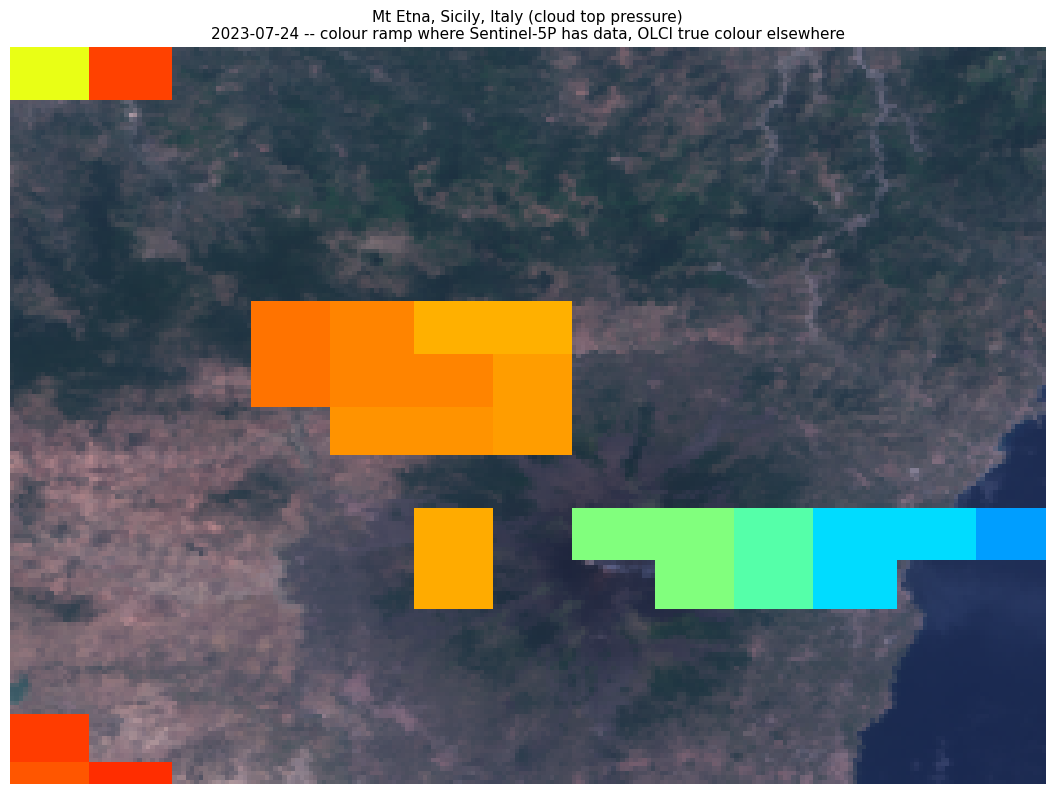

In [10]:
img = Image.open(result_filename)

fig, ax = plt.subplots(figsize=(11, 8), dpi=100)
ax.imshow(img)
ax.set_title(
    f"{current_params['location_name']}\n{current_params['time'].default[0]}"
    " -- colour ramp where Sentinel-5P has data, OLCI true colour elsewhere",
    fontsize=11,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Validation Across Three More Product/Location Pairs

The same graph, unchanged, is re-run for three more `(product, location)` pairs
chosen to exercise the colour ramp under real conditions rather than a single
synthetic case:

- **SO2 over Mt Etna** -- same bounding box and date as the primary example
  above, a direct product swap at one location.
- **NO2 over the Po Valley** -- one of Europe's most persistent NO2 hotspots.
- **CO over Chiquitania, Bolivia** -- the 2019 dry-forest fire complex also used
  by `s2_s1_forest_fire_progression.ipynb`, during Bolivia's worst wildfire
  season on record.

In [11]:
def build_and_download(set_name, endpoint):
    """Re-run the same fusion graph for a different parameter set."""
    _, params = param_manager.quick_connect(param_set=set_name, endpoint=endpoint, silent=True)

    s5p_spec = param_manager.apply_endpoint_mapping(
        {"collection": params["s5p_collection"], "bands": params["s5p_bands"]}, endpoint
    )
    product = param_manager.get_parameter("s5p_bands", set_name).default[0]
    limits = limits_for(product)

    _olci = connection.load_collection(
        params["collection"].default,
        temporal_extent=params["time"],
        spatial_extent=params["bounding_box"],
        bands=params["bands"].default,
    ).reduce_dimension(dimension=params["time_dimension"], reducer="mean")

    _s5p_cube = connection.load_collection(
        s5p_spec["collection"].default,
        temporal_extent=params["time"],
        spatial_extent=params["bounding_box"],
        bands=s5p_spec["bands"].default,
    ).reduce_dimension(dimension=params["time_dimension"], reducer="mean")

    _fused = _olci.merge_cubes(_s5p_cube.resample_cube_spatial(_olci, method="near"))

    def _reducer(data):
        b04, b06, b08, value = data[0], data[1], data[2], data[3]
        has_data = value > 0
        r = if_(has_data, color_blend_channel(value, limits, 0), (b08 * 3).clip(min=0, max=1))
        g = if_(has_data, color_blend_channel(value, limits, 1), (b06 * 3).clip(min=0, max=1))
        b = if_(has_data, color_blend_channel(value, limits, 2), (b04 * 3.5).clip(min=0, max=1))
        return array_create([r, g, b])

    _rgb = _fused.reduce_dimension(dimension=params["bands_dimension"], reducer=_reducer)
    _rgb = _rgb.linear_scale_range(0, 1, 0, 255).save_result("PNG")

    _file = f"{_algorithm_id}_{set_name}.png"
    param_manager.resolve(_rgb, params).download(_file)
    return _file, params, product


validation_sets = ["etna_sicily_so2", "po_valley_no2", "chiquitania_co"]
validation_outputs = {}
for set_name in validation_sets:
    _file, _params, _product = build_and_download(set_name, _endpoint)
    validation_outputs[set_name] = (_file, _params, _product)
    print(f"✅ {set_name}: {_file} (product: {_product})")

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set(_primary_set)

Authenticated using refresh token.


✅ etna_sicily_so2: olci_under_s5_etna_sicily_so2.png (product: so2)


Authenticated using refresh token.


✅ po_valley_no2: olci_under_s5_po_valley_no2.png (product: no2)


Authenticated using refresh token.


✅ chiquitania_co: olci_under_s5_chiquitania_co.png (product: co)


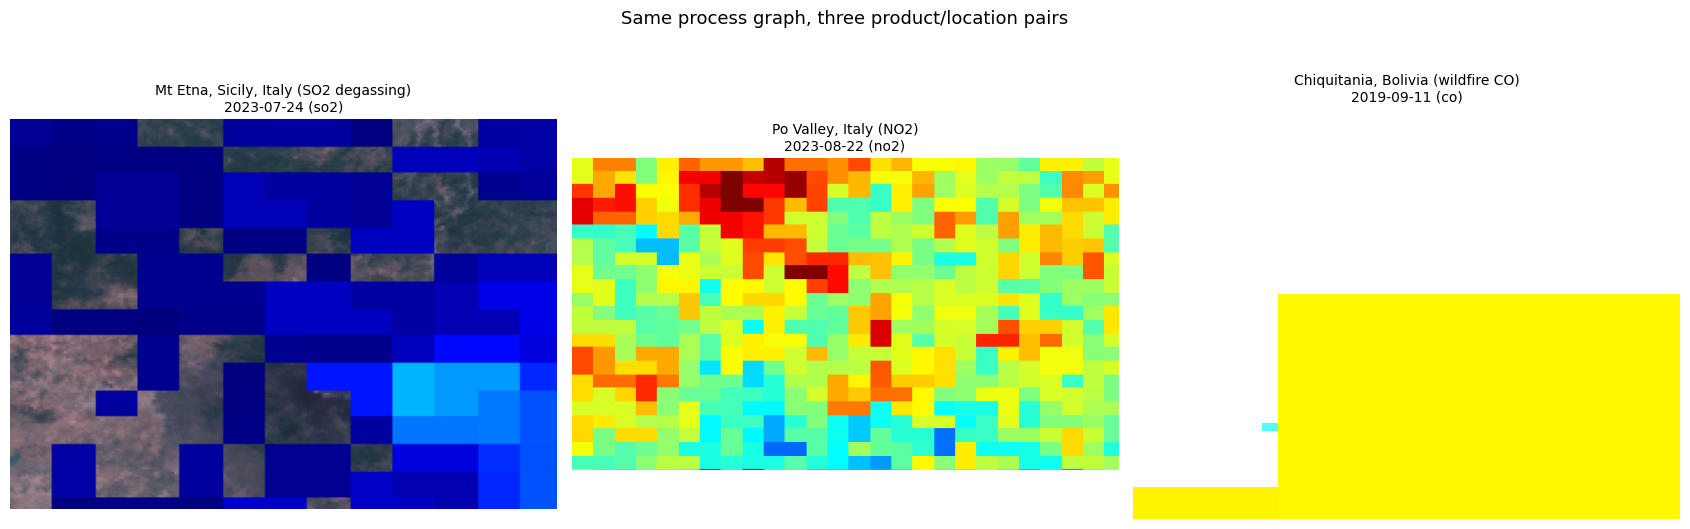

In [12]:
validation_fig, validation_axes = plt.subplots(1, len(validation_outputs), figsize=(17, 6))
for ax, set_name in zip(np.atleast_1d(validation_axes), validation_sets, strict=True):
    v_file, v_params, v_product = validation_outputs[set_name]
    ax.imshow(Image.open(v_file))
    ax.set_title(f"{v_params['location_name']}\n{v_params['time'].default[0]} ({v_product})", fontsize=10)
    ax.axis("off")
validation_fig.suptitle("Same process graph, three product/location pairs", fontsize=13)
plt.tight_layout()
plt.show()

### What the validation shows

- **SO2 over Mt Etna** is dominated by low, near-background values (dark blue)
  across most of the frame, with only a corner of OLCI true colour showing
  through where the product had no data that day. Etna degasses SO2
  continuously, but passive degassing is often narrower than TROPOMI's ~7 km
  footprint can resolve, so a quiet day reads as background rather than a
  distinct plume -- a real limitation of the sensor, not of this conversion.
- **NO2 over the Po Valley** shows a strong, well-defined signal with a clear
  hotspot, and Sentinel-5P has full coverage of the frame -- NO2's high spatial
  variability over industrial/urban sources makes it one of TROPOMI's most
  visually distinctive products.
- **CO over Chiquitania** reads as a broad, fairly uniform elevated value across
  almost the entire frame -- consistent with a large regional smoke plume from
  one of Bolivia's most severe wildfire seasons, rather than a single
  point-source plume. The small bright patch is a bright cloud in the OLCI
  true-colour fallback, saturating all three channels to white.

All three confirm the same behaviour: the colour ramp tracks the product's own
`(min, max)` range correctly, and OLCI shows through cleanly wherever the
product is non-positive.

## Limitations and Differences from the Original

- **The product is chosen at graph-construction time, not at runtime.** CDSE's
  `SENTINEL_5P_L2` collection only supports one band per request, and each
  product needs its own `(min, max)` colour-ramp range -- both are baked into
  the exported graph via `.default`, mirroring how the original evalscript is
  repurposed by hand-editing the script text (see its own "replace all
  `CLOUD_TOP_PRESSURE` mentions" comment). Only `bounding_box` and `time` are
  exposed as runtime UDP parameters.
- **The validity test is `value > 0`, not a proper no-data mask.** The
  collection carries a `dataMask` band that the original evalscript does not
  use, and neither does this conversion, to stay faithful. A genuinely valid
  but exactly-zero product reading (plausible for some gases over a very clean
  atmosphere) would be misclassified as "no data" and fall through to the OLCI
  true-colour composite. This is an inherited limitation of the original
  script, not introduced here.
- **TROPOMI's ~7 km footprint is visible as blockiness** against the 300 m OLCI
  grid, exactly as in the Sentinel-3 LST notebook's SLSTR/OLCI fusion.
  Nearest-neighbour resampling does not invent structure the retrieval does not
  have.
- **Output is a colour image, not a physical quantity** -- a deliberate
  departure from the LST notebook's choice to export temperature. The original
  evalscript *is* a visualisation, so an RGB PNG is the faithful conversion
  here; anyone needing the raw product values should load `SENTINEL_5P_L2`
  directly.
- **No cloud handling on the OLCI side.** Where Sentinel-5P has no data and OLCI
  itself is cloudy, the fallback branch renders the cloud in true colour (as
  seen in the Chiquitania example) rather than masking it -- matching the
  original, which has no OLCI cloud mask either.
- **Same-day acquisitions are not guaranteed to be simultaneous.** OLCI and
  Sentinel-5P do not share an orbit; a one-day window can pair scenes from
  different times, which mostly matters for genuinely fast-moving atmospheric
  features (fresh smoke plumes, frontal cloud systems).

## Export the Process Graph

The exported UDP returns an RGB visualisation as a PNG. Its parameters are the
area of interest and the time window; the OLCI/Sentinel-5P collections, their
bands (i.e. the chosen product), and the colour-ramp range stay intrinsic to
the algorithm.

In [13]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "notebooks").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

In [14]:
# Export the process graph for reuse as a parameterized UDP
import json

process_graph = {
    "process_graph": rgb_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Sentinel-3 OLCI true colour overlaid with a Sentinel-5P atmospheric product using openEO.",
    "description": (
        "Overlays a single Sentinel-5P (TROPOMI) atmospheric product -- cloud "
        "pressure/height, a trace gas, aerosol index, or cloud fraction/optical "
        "thickness -- as a six-stop colour ramp on top of a Sentinel-3 OLCI "
        "true-colour base map. Wherever the Sentinel-5P product has no data, "
        "the OLCI true-colour pixel shows through instead, so the output is "
        "never empty. The Sentinel-5P band is resampled onto OLCI's 300 m grid "
        "with nearest-neighbour before fusion. Converted from the Sentinel Hub "
        "'OLCI true colour under Sentinel-5P products' evalscript by Monja B. "
        "Šebela."
    ),
}

with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

Process graph exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/olci_under_s5/openeo_udp/olci_under_s5.json
Process ID: olci_under_s5


In [15]:
# Export metadata to register the process graph in the APEx Algorithm Catalogue.
# Self-contained (recomputes _repo_root/_algorithm_id) because populate_record.py
# execs this cell in isolation, by cell tag, not by running the whole notebook.
from pathlib import Path

if "_algorithm_id" not in globals():
    _algorithm_id = "olci_under_s5"

_repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks").exists())
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

metadata = {
    "id": _algorithm_id,
    "title": "OLCI True Colour Under Sentinel-5P Products",
    "preview_title": "OLCI True Colour Under Sentinel-5P Products",
    "description": (
        "Overlays a Sentinel-5P (TROPOMI) atmospheric product as a colour ramp "
        "on top of a Sentinel-3 OLCI true-colour base map, falling back to the "
        "true-colour image wherever the atmospheric product has no data. "
        "Supports cloud pressure/height/fraction/optical thickness, trace gases "
        "(CO, HCHO, NO2, O3, SO2, CH4), and UV aerosol index."
    ),
    "keywords": [
        "Data fusion",
        "Atmospheric composition",
        "Air quality",
        "Sentinel-3",
        "Sentinel-5P",
        "TROPOMI",
        "OLCI",
        "True color",
    ],
    "themes": ["ATMOSPHERE", "AIR QUALITY", "REMOTE SENSING", "Sentinel-3", "Sentinel-5P"],
    "created": "2026-07-30T00:00:00Z",
    "updated": "2026-07-30T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": "CDSE openEO Federation",
    "openeo_backend_url": "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location": _nb_href,
    "collection_id": "SENTINEL3_OLCI_L1B",
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/data-fusion/olci_under_s5/",
        "authors": ["Monja B. Šebela"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": (
            "Veefkind, J.P., et al. (2012). TROPOMI on the ESA Sentinel-5 "
            "Precursor: A GMES mission for global observations of the "
            "atmospheric composition for climate, air quality and ozone layer "
            "applications. Remote Sensing of Environment, 120, 70-83."
        ),
    },
}

In [16]:
# Export the process graph and register the UDP + preview into algorithm_registration/
from algorithm_registration.register_algorithm import register

udp_path = Path(f"{_algorithm_id}.json")
with open(udp_path, "w") as f:
    json.dump(process_graph, f, indent=2)

register(
    notebook_path=Path.cwd() / f"{_algorithm_id}.ipynb",
    udp_path=udp_path,
    preview_fig=fig,
)

Algorithm directory: /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/olci_under_s5
UDP registered: /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/olci_under_s5/openeo_udp/olci_under_s5.json
Preview registered from figure: /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/olci_under_s5/records/preview.png
Notebook : /home/emathot/Workspace/DevelopmentSeed/openeo-udp/notebooks/sentinel/sentinel-3/olci_under_s5.ipynb
Template : /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/records_template.json
Metadata extracted — id: 'olci_under_s5'
Record written: /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/olci_under_s5/records/olci_under_s5.json


Thumbnail written: /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/olci_under_s5/records/thumbnail.png
Commit all the records before pushing to openeo-udp repository


PosixPath('/home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/olci_under_s5')

## References and Attribution

**Original Script:** [OLCI true colour under Sentinel-5P products](https://custom-scripts.sentinel-hub.com/data-fusion/olci_under_s5/)

**Author:** Monja B. Šebela

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- Veefkind, J.P., et al. (2012). TROPOMI on the ESA Sentinel-5 Precursor: A GMES
  mission for global observations of the atmospheric composition for climate,
  air quality and ozone layer applications. *Remote Sensing of Environment*,
  120, 70-83. -- the TROPOMI instrument this notebook's Sentinel-5P products
  come from.
- Sentinel-3 OLCI is documented in ESA's Sentinel-3 User Handbook.

### openEO Conversion

- **Conversion Date**: 30 July 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem) -- the only backend
  in this repository serving Sentinel-5P
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the OLCI-under-Sentinel-5P data-fusion evalscript into an
openEO User-Defined Process. The implementation:

✅ **Reproduces the colour ramp and gap-fill logic exactly** -- verified pixel by
pixel against a numpy reimplementation of `colorBlend` and the `value > 0`
validity test.

✅ **Handles the "one band at a time" restriction** on CDSE's `SENTINEL_5P_L2`
collection by baking the chosen product into the graph, alongside its
colour-ramp range from a shared `S5P_PRODUCT_RANGES` table.

✅ **Fuses two different missions onto a common grid** -- resampling the ~7 km
Sentinel-5P product onto the 300 m OLCI grid with nearest-neighbour, the same
pattern used for the SLSTR/OLCI fusion in the Sentinel-3 LST notebook.

✅ **Is tested across four product/location pairs** -- cloud top pressure and
SO2 over Mt Etna, NO2 over the Po Valley, and CO over the 2019 Chiquitania
wildfires -- rather than a single synthetic case.

### Key conversion notes

- `bounding_box` and `time` are the UDP parameters; the OLCI/Sentinel-5P
  collections, bands (i.e. product choice) and colour-ramp ranges are
  intrinsic.
- Output is an RGB PNG, matching the original's own purpose as a visualisation.
- CDSE is currently the only backend this UDP can run on, since it is the only
  one in this repository with a Sentinel-5P mapping.

### Possible extensions

- Use the collection's `dataMask` band for a proper no-data test instead of
  `value > 0`.
- Expose the product as a true runtime UDP parameter once openEO gains a
  standard way to parameterise `load_collection` band selection per call.
- Composite several Sentinel-5P overpasses to fill gaps within the product
  itself, before falling back to OLCI.